In [3]:
from data_loader import baixar_dataset_kaggle, carregar_csv


In [4]:
baixar_dataset_kaggle('yasserh/heart-disease-dataset','../data/raw',True)

Dataset URL: https://www.kaggle.com/datasets/yasserh/heart-disease-dataset


WindowsPath('../data/raw')

# Importação de bibliotecas - Exploração de dados
* Pandas
* Seaborn
* Numpy
* Statistic
* Matplot

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statistics as sts

In [6]:
df = carregar_csv('../data/raw/heart.csv')

In [7]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [8]:
df.columns = ["Idade", "Sexo", "dor_toracica", "Pa_Repouso", "colesterol", "glicemia", "resultado_ECG", "FC_Max", "Angina_exe", "ST_depre_exerc", "Pico_ST_exerc", "fluroscopia_vasos_principais", "Defeito_reversivel", "Cardiaco"]

In [9]:
df.shape

(303, 14)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Idade                         303 non-null    int64  
 1   Sexo                          303 non-null    int64  
 2   dor_toracica                  303 non-null    int64  
 3   Pa_Repouso                    303 non-null    int64  
 4   colesterol                    303 non-null    int64  
 5   glicemia                      303 non-null    int64  
 6   resultado_ECG                 303 non-null    int64  
 7   FC_Max                        303 non-null    int64  
 8   Angina_exe                    303 non-null    int64  
 9   ST_depre_exerc                303 non-null    float64
 10  Pico_ST_exerc                 303 non-null    int64  
 11  fluroscopia_vasos_principais  303 non-null    int64  
 12  Defeito_reversivel            303 non-null    int64  
 13  Cardi

In [11]:
duplicados = df[df.duplicated(keep=False)]
print(duplicados)

     Idade  Sexo  dor_toracica  Pa_Repouso  colesterol  glicemia  \
163     38     1             2         138         175         0   
164     38     1             2         138         175         0   

     resultado_ECG  FC_Max  Angina_exe  ST_depre_exerc  Pico_ST_exerc  \
163              1     173           0             0.0              2   
164              1     173           0             0.0              2   

     fluroscopia_vasos_principais  Defeito_reversivel  Cardiaco  
163                             4                   2         1  
164                             4                   2         1  


In [12]:
df.drop_duplicates(keep="first", inplace=True)


In [13]:
df.shape

(302, 14)

* Quantos pacientes possuem doença cardíaca?
* Quantos não possuem?
* Qual o percentual de cada grupo?


In [14]:
cardiacos = df["Cardiaco"].value_counts()
Percentual_cardiacos = df['Cardiaco'].value_counts(normalize=True) * 100
print(cardiacos)
print(Percentual_cardiacos)

'''
A amostra analisada apresenta distribuição relativamente equilibrada 
entre pacientes diagnosticados e não diagnosticados com doença cardíaca, 
representando aproximadamente 54% e 46% dos registros, respectivamente.

'''

Cardiaco
1    164
0    138
Name: count, dtype: int64
Cardiaco
1    54.304636
0    45.695364
Name: proportion, dtype: float64


'\nA amostra analisada apresenta distribuição relativamente equilibrada \nentre pacientes diagnosticados e não diagnosticados com doença cardíaca, \nrepresentando aproximadamente 54% e 46% dos registros, respectivamente.\n\n'

### Estatística descritiva

In [15]:
# sexo = 1 = homem; 0 = mulher
sexo = df['Sexo'].value_counts()
percentual_sexo = df["Sexo"].value_counts(normalize=True) * 100
print(sexo)
print(percentual_sexo)

Sexo
1    206
0     96
Name: count, dtype: int64
Sexo
1    68.211921
0    31.788079
Name: proportion, dtype: float64


In [16]:
idade = df['Idade'].describe()
print(f' idade = {idade}')
# Pa = df['Pa_Repouso'].describe()
Pa_mediana = df['Pa_Repouso'].mean()
Pa_media = df['Pa_Repouso'].median()
Pa_maxima = df['Pa_Repouso'].max()
Pa_minima = df['Pa_Repouso'].min()
Pa_desvio = df['Pa_Repouso'].std()
print(f' PA_mediana = {Pa_mediana},',
      f" PA_media = {Pa_media},",
      f" PA_maxima {Pa_maxima},",
      f' PA_minima {Pa_minima},',
      f' PA_minima {Pa_minima},',
      f' PA_desvio {Pa_desvio}')
 


 idade = count    302.00000
mean      54.42053
std        9.04797
min       29.00000
25%       48.00000
50%       55.50000
75%       61.00000
max       77.00000
Name: Idade, dtype: float64
 PA_mediana = 131.60264900662253,  PA_media = 130.0,  PA_maxima 200,  PA_minima 94,  PA_minima 94,  PA_desvio 17.56339423003756


In [17]:
idade = df['Idade'].describe()
print(f' idade = {idade}')
Pa = df['Pa_Repouso'].describe()
print(f' Pa_Repouso = {Pa}')
colesterol = df['colesterol'].describe()
print(f' Colesterol = {colesterol}')
Fc = df['FC_Max'].describe()
print(f' FC = {Fc}')
ST_exercicio = df['ST_depre_exerc'].describe()
print(f' ST Depressão = {ST_exercicio}')

 idade = count    302.00000
mean      54.42053
std        9.04797
min       29.00000
25%       48.00000
50%       55.50000
75%       61.00000
max       77.00000
Name: Idade, dtype: float64
 Pa_Repouso = count    302.000000
mean     131.602649
std       17.563394
min       94.000000
25%      120.000000
50%      130.000000
75%      140.000000
max      200.000000
Name: Pa_Repouso, dtype: float64
 Colesterol = count    302.000000
mean     246.500000
std       51.753489
min      126.000000
25%      211.000000
50%      240.500000
75%      274.750000
max      564.000000
Name: colesterol, dtype: float64
 FC = count    302.000000
mean     149.569536
std       22.903527
min       71.000000
25%      133.250000
50%      152.500000
75%      166.000000
max      202.000000
Name: FC_Max, dtype: float64
 ST Depressão = count    302.000000
mean       1.043046
std        1.161452
min        0.000000
25%        0.000000
50%        0.800000
75%        1.600000
max        6.200000
Name: ST_depre_exerc, dtyp

Text(0.5, 1.0, 'Idade')


C:\Users\dyego\AppData\Local\Temp\ipykernel_29620\2061701473.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  print(sns.distplot(df["Idade"]).set_title("Idade"))


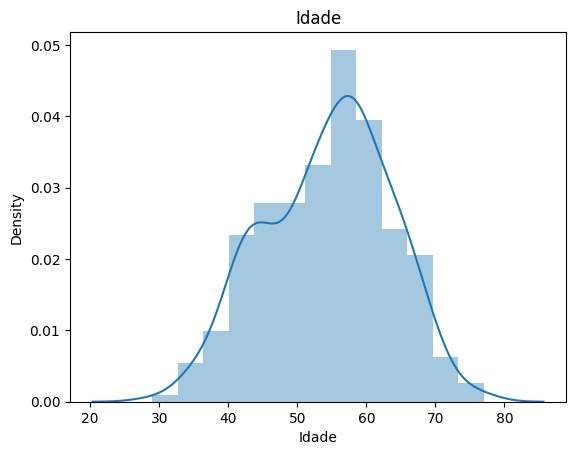

In [18]:
print(sns.distplot(df["Idade"]).set_title("Idade"))
# print(plt.hist(df["Idade"]))


Text(0.5, 1.0, 'Idade')


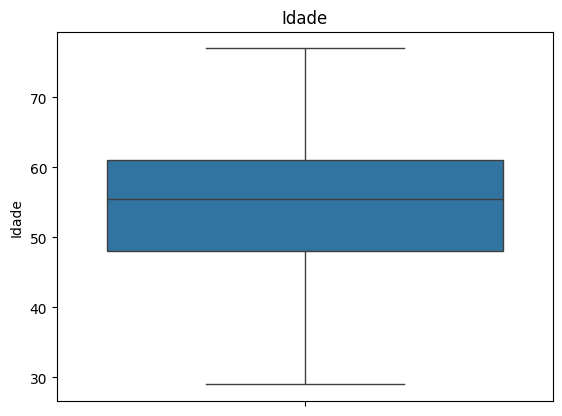

In [19]:
print(sns.boxplot(df['Idade']).set_title("Idade"))
# print(plt.boxplot(df['Idade']))

* A variável idade apresenta distribuição aproximadamente normal, com maior concentração de pacientes entre 50 e 65 anos. Observa-se apenas uma leve assimetria, sem indícios visuais de distorções significativas na distribuição.

C:\Users\dyego\AppData\Local\Temp\ipykernel_29620\3443576166.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Pa_Repouso'], bins=10).set_title("Histograma PA em Repouso")


Text(0.5, 1.0, 'Histograma PA em Repouso')

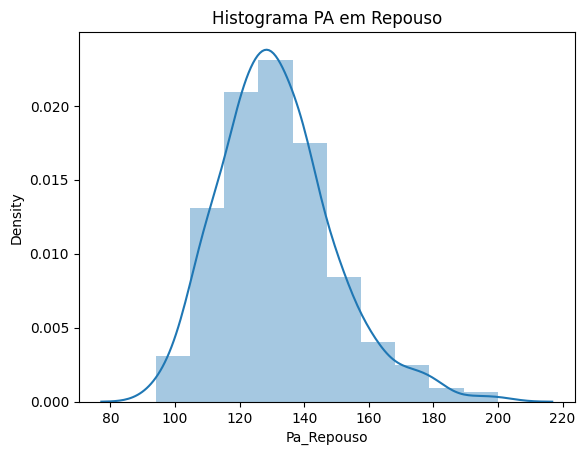

In [20]:
sns.distplot(df['Pa_Repouso'], bins=10).set_title("Histograma PA em Repouso")

Text(0.5, 1.0, 'PA em Repouso')

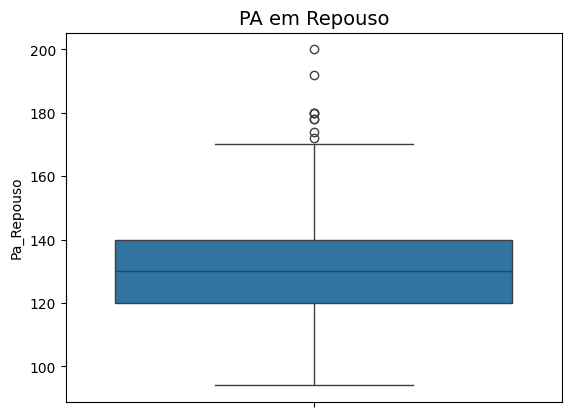

In [21]:
sns.boxplot(df["Pa_Repouso"]).set_title("PA em Repouso", fontsize=14)

* A pressão arterial em repouso apresenta distribuição levemente assimétrica à direita, indicando a presença de pacientes com níveis pressóricos significativamente superiores à média da amostra. O boxplot identificou múltiplos valores extremos acima do limite superior, porém esses registros permanecem plausíveis dentro do contexto clínico e foram mantidos para análises posteriores.

C:\Users\dyego\AppData\Local\Temp\ipykernel_29620\394196998.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["colesterol"], bins=10)


<Axes: xlabel='colesterol', ylabel='Density'>

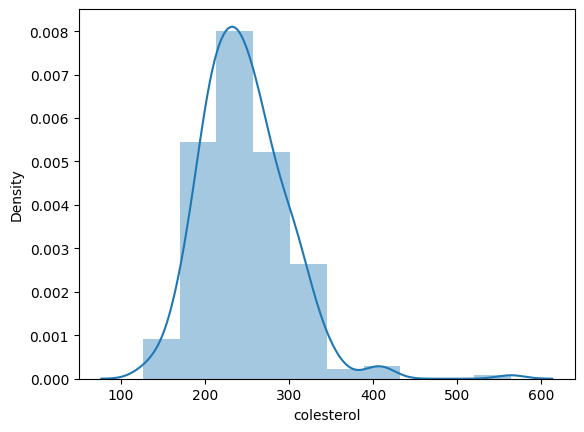

In [22]:
sns.distplot(df["colesterol"], bins=10)

<Axes: ylabel='colesterol'>

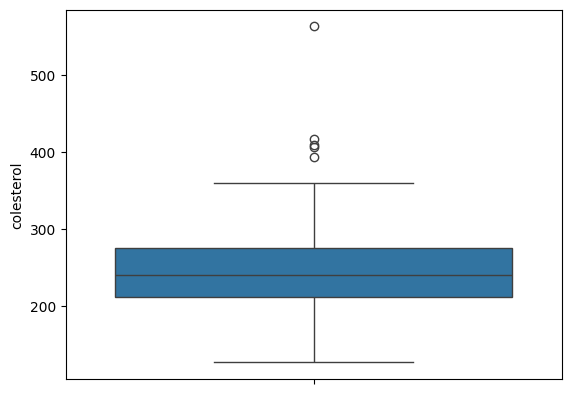

In [23]:
sns.boxplot(df["colesterol"])

* A variável colesterol apresenta distribuição assimétrica à direita, indicando a presença de pacientes com níveis de colesterol significativamente superiores à maioria da amostra. O boxplot revelou diversos valores extremos acima do limite superior, porém estes permanecem clinicamente plausíveis e foram mantidos para análises posteriores.

C:\Users\dyego\AppData\Local\Temp\ipykernel_29620\558059802.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["FC_Max"], bins=10)


<Axes: xlabel='FC_Max', ylabel='Density'>

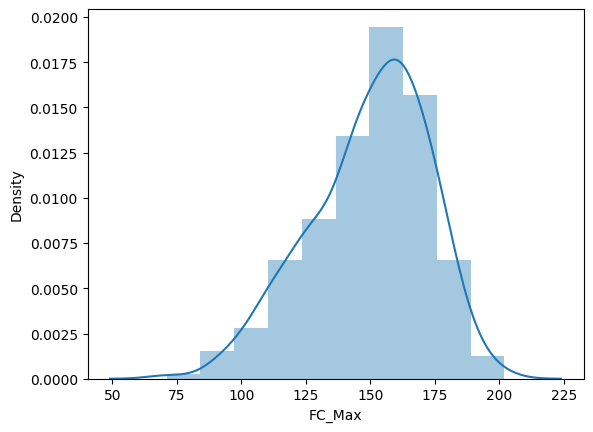

In [24]:
sns.distplot(df["FC_Max"], bins=10)

Text(0.5, 1.0, 'FC_max')

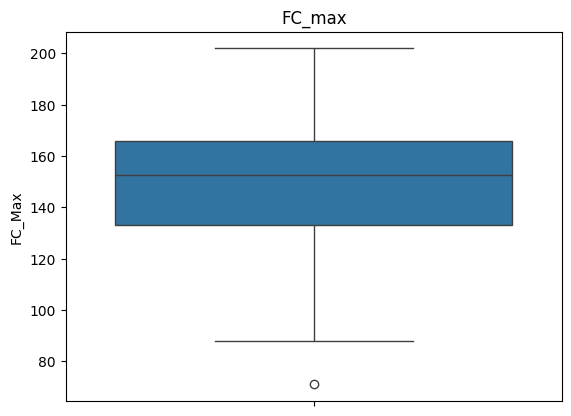

In [25]:
sns.boxplot(df["FC_Max"]).set_title("FC_max")

* A frequência cardíaca máxima apresenta distribuição relativamente equilibrada, com maior concentração dos pacientes entre 140 e 170 bpm. A proximidade entre média e mediana sugere baixa distorção da distribuição e reduzida influência de valores extremos.

C:\Users\dyego\AppData\Local\Temp\ipykernel_29620\582628868.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['ST_depre_exerc'], bins=10)


<Axes: xlabel='ST_depre_exerc', ylabel='Density'>

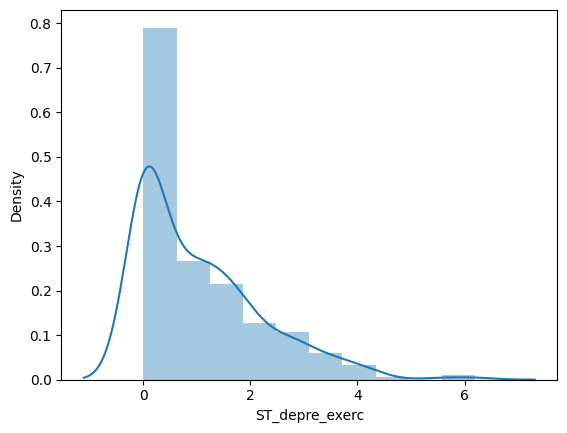

In [26]:
sns.distplot(df['ST_depre_exerc'], bins=10)

Text(0.5, 1.0, 'ST despressão')

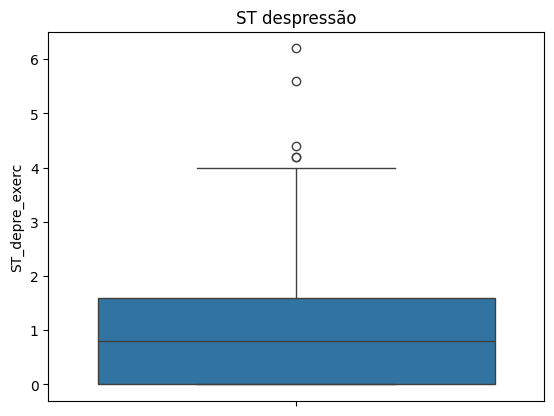

In [27]:
sns.boxplot(df['ST_depre_exerc']).set_title("ST despressão")

* A variável ST_depre_exerc apresenta forte assimetria positiva, indicando que a maioria dos pacientes possui baixos níveis de depressão do segmento ST, enquanto um pequeno grupo apresenta valores significativamente mais elevados.

In [ ]:
""" 
O dicionario de dados não informa os criterios de avaliação e o que corresponde cada 
valor, mas por experiencia de hospitais sempre para risco de infarto utiliza-se
Definitivamente Anginosa (Tipo A): Apresenta as características clássicas: 
dor em aperto ou queimação no centro do peito, desencadeada por esforço físico
ou estresse, e que melhora com repouso ou uso de nitratos. 
Provavelmente Anginosa (Tipo B): Apresenta pelo menos duas das características
clássicas mencionadas acima. 
Provavelmente Não Anginosa (Tipo C): Apresenta apenas uma das características 
clássicas, mas possui múltiplos fatores de risco ou exige investigação para 
descartar problemas coronarianos. 
Definitivamente Não Anginosa (Tipo D): Não apresenta as características típicas de
angina. Geralmente está ligada a outras origens, como problemas musculares, 
pulmonares ou gastrointestinais. 
"""

# dor_toracica = df['dor_toracica'].value_counts(normalize=True).sort_index()
dor_toracica = df['dor_toracica'].value_counts()
dor_toracica = round((dor_toracica / len(df)) * 100),.2
dor_toracica

(dor_toracica
 0    47.0
 2    28.0
 1    17.0
 3     8.0
 Name: count, dtype: float64,
 0.2)

* A variável dor_toracica apresenta quatro categorias codificadas (0–3). O dicionário de dados não descreve explicitamente o significado clínico de cada código. Embora seja possível formular hipóteses baseadas no conhecimento clínico, a interpretação definitiva será realizada após a análise da relação entre as categorias e a variável alvo Cardiaco.

In [47]:
glicemia = df['glicemia'].value_counts().sort_index()
glicemia

glicemia
0    257
1     45
Name: count, dtype: int64

In [48]:
Ecg = df["resultado_ECG"].value_counts().sort_index()
Ecg

resultado_ECG
0    147
1    151
2      4
Name: count, dtype: int64

In [49]:
Angina_exerc = df['Angina_exe'].value_counts().sort_index()
Angina_exerc

Angina_exe
0    203
1     99
Name: count, dtype: int64